# Проект: Многоцелевая модель для NER + event-CLS

Этот Jupyter-ноутбук - пошаговый шаблон для выполнения проекта по объединённой (multi-task) модели, решающей **NER (BIO, token-level)** и **CLS (document-level multihot событий/отношений)** на датасете NEREL.

Модель должна решать параллельно две задачи: классифицировать токены на BIO-теги и классифицировать текст на принадлежность к 30 классам-характеристикам текста.

Характеристики:
```
['WORKPLACE', 'ALTERNATIVE_NAME', 'WORKS_AS', 'PARTICIPANT_IN', 'POINT_IN_TIME', 'TAKES_PLACE_IN', 'HEADQUARTERED_IN', 'ORIGINS_FROM', 'LOCATED_IN', 'AGENT', 'AGE_IS', 'HAS_CAUSE', 'PRODUCES', 'AWARDED_WITH', 'PART_OF', 'IDEOLOGY_OF', 'MEMBER_OF', 'CONVICTED_OF', 'INANIMATE_INVOLVED', 'SUBEVENT_OF', 'SUBORDINATE_OF', 'KNOWS', 'MEDICAL_CONDITION', 'PARENT_OF', 'PLACE_RESIDES_IN', 'OWNER_OF', 'ABBREVIATION', 'FOUNDED_BY', 'ORGANIZES', 'PENALIZED_AS']
```

Внимание: вам нужно реализовать весь рабочий код - в ноутбуке реализована только загрузка датасета. Все остальные ячейки служат как инструкции / места для вашего кода.


#### Структура ноутбука

1. Подготовка окружения (пути, seed, imports)
2. EDA - загрузка данных, обзор, графики, выводы
3. Токенизация, выравнивание меток, DataLoader - реализовать `tokenize_and_align_labels`, Dataset/Collator
4. Модель (JointModel) и кастомный loss (uncertainty-weighting) - реализовать модельный класс и loss
5. Тренировка/валидация - training loop, оптимизатор, scheduler, логирование метрик
6. Инференс и анализ ошибок - реализовать inference pipeline и примеры



##### 1. EDA

Цели:

- Прочитать 3 записи датасета.
- Посчитать встречаемость каждого класса в cls_vec.
- Построить графики: распределение длины текстов, число сущностей на документ.
- Написать 2–3 коротких вывода в Markdown: что можно ожидать при моделировании (редкие типы, длинные документы и т. п.).




In [48]:
features = ['WORKPLACE', 'ALTERNATIVE_NAME', 'WORKS_AS', 'PARTICIPANT_IN', 'POINT_IN_TIME',
    'TAKES_PLACE_IN', 'HEADQUARTERED_IN', 'ORIGINS_FROM', 'LOCATED_IN', 'AGENT', 
    'AGE_IS', 'HAS_CAUSE', 'PRODUCES', 'AWARDED_WITH', 'PART_OF', 'IDEOLOGY_OF', 
    'MEMBER_OF', 'CONVICTED_OF', 'INANIMATE_INVOLVED', 'SUBEVENT_OF', 'SUBORDINATE_OF', 
    'KNOWS', 'MEDICAL_CONDITION', 'PARENT_OF', 'PLACE_RESIDES_IN', 'OWNER_OF', 
    'ABBREVIATION', 'FOUNDED_BY', 'ORGANIZES', 'PENALIZED_AS']

Посмотрим на датасет

In [49]:
from datasets import load_dataset
dataset = load_dataset("danasone/nerel")
dataset

DatasetDict({
    train: Dataset({
        features: ['tokens', 'token_spans', 'tags', 'cls_vec', 'text'],
        num_rows: 746
    })
})

Датасет состоит из сплита train. Для обучение выделим из него val и test подвыборки.

Выведем 3 записи датасета

In [50]:
for i in range(3):
    print(f"---\nТЕКСТ {i+1}:\n")
    for k in dataset["train"].features.keys():
        print(f"{k}:")
        print(dataset["train"][i][k])
        print()

---
ТЕКСТ 1:

tokens:
['Пулеметы,', 'автоматы', 'и', 'снайперские', 'винтовки', 'изъяты', 'в', 'арендуемом', 'американцами', 'доме', 'в', 'Бишкеке', '05/08/2008', '10:35', 'БИШКЕК,', '5', 'августа', '/Новости-Грузия/.', 'Правоохранительные', 'органы', 'Киргизии', 'обнаружили', 'в', 'доме,', 'арендуемом', 'гражданами', 'США', 'в', 'Бишкеке,', 'пулеметы,', 'автоматы', 'и', 'снайперские', 'винтовки,', 'сообщает', 'во', 'вторник', 'пресс-служба', 'МВД', 'Киргизии.', '"В', 'ходе', 'проведения', 'оперативно-профилактического', 'мероприятия', 'под', 'кодовым', 'названием', '"Арсенал"', 'в', 'новостройке', 'Ынтымак,', 'в', 'доме,', 'принадлежащем', '66-летнему', 'гражданину', 'Киргизии', 'и', 'арендуемом', 'гражданами', 'США,', 'обнаружены', 'и', 'изъяты:', 'шесть', 'крупнокалиберных', 'пулеметов', 'с', 'оптическим', 'прицелом', 'и', 'с', 'приборами', 'ночного', 'видения,', '26', 'автоматов', 'калибра', '5,56', 'миллиметра,', 'два', 'винчестера', 'марки', 'МОСВЕГА', '12-го', 'калибра,', 'четыр

Посчитаем встречаемость характеристик в датасете

In [51]:
features_cnt = {k: 0 for k in features}

for row in dataset["train"]:
    for feature, flag in zip(features, row["cls_vec"]):
        if flag:
            features_cnt[feature] += 1

features_cnt

{'WORKPLACE': 609,
 'ALTERNATIVE_NAME': 723,
 'WORKS_AS': 678,
 'PARTICIPANT_IN': 656,
 'POINT_IN_TIME': 600,
 'TAKES_PLACE_IN': 545,
 'HEADQUARTERED_IN': 518,
 'ORIGINS_FROM': 449,
 'LOCATED_IN': 454,
 'AGENT': 421,
 'AGE_IS': 535,
 'HAS_CAUSE': 282,
 'PRODUCES': 195,
 'AWARDED_WITH': 137,
 'PART_OF': 214,
 'IDEOLOGY_OF': 119,
 'MEMBER_OF': 150,
 'CONVICTED_OF': 133,
 'INANIMATE_INVOLVED': 174,
 'SUBEVENT_OF': 170,
 'SUBORDINATE_OF': 132,
 'KNOWS': 149,
 'MEDICAL_CONDITION': 106,
 'PARENT_OF': 98,
 'PLACE_RESIDES_IN': 125,
 'OWNER_OF': 114,
 'ABBREVIATION': 142,
 'FOUNDED_BY': 98,
 'ORGANIZES': 121,
 'PENALIZED_AS': 78}

Оценим кол-во сущностей в датасете

In [52]:
from collections import Counter

Counter([item.split("-")[1] for row in dataset["train"] for item in row["tags"] if "B-" in item])

Counter({'PERSON': 7343,
         'PROFESSION': 5193,
         'EVENT': 4318,
         'ORGANIZATION': 3768,
         'DATE': 3548,
         'COUNTRY': 1858,
         'NUMBER': 1260,
         'CITY': 1206,
         'AGE': 901,
         'NATIONALITY': 572,
         'FACILITY': 537,
         'ORDINAL': 482,
         'WORK_OF_ART': 482,
         'AWARD': 450,
         'CRIME': 405,
         'PRODUCT': 379,
         'LAW': 347,
         'DISEASE': 328,
         'STATE_OR_PROVINCE': 326,
         'IDEOLOGY': 277,
         'LOCATION': 275,
         'TIME': 250,
         'MONEY': 230,
         'PENALTY': 206,
         'PERCENT': 102,
         'DISTRICT': 101,
         'RELIGION': 73,
         'LANGUAGE': 67,
         'FAMILY': 30})

Построим график распределения длин текстов и числа сущностей на документ

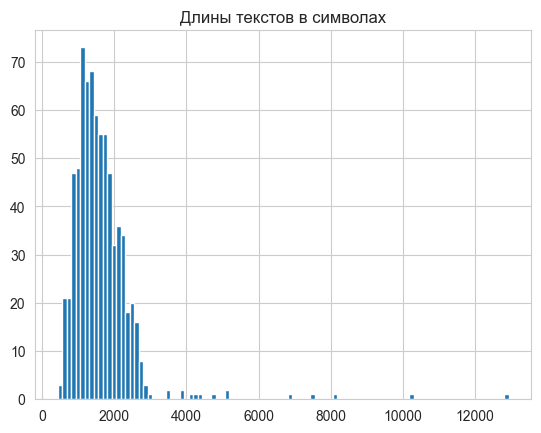

In [53]:
from matplotlib import pyplot as plt

text_lengths = [len(row["text"]) for row in dataset["train"]]

# график распределения длин текстов
plt.hist(text_lengths, bins=100)
plt.title("Длины текстов в символах")
plt.show()

In [54]:
texts = [row["text"] for row in dataset['train']]

print("---\nТоп 3 самых коротких текста\n")
for idx, text in enumerate(sorted(texts, key=len)[:3]):
    print(f"Текст {idx+1}\n")
    print(text + "\n")

---
Топ 3 самых коротких текста

Текст 1

Ларри Пейдж и Сергей Брин перестали возглавлять Google
Создатели Google Ларри Пейдж и Сергей Брин покинули свои места в материнской компании Alphabet.
Генеральным директором Alphabet станет гендиректор Google Сундар Пичаи, который будет совмещать два поста.

В заявлении основателей корпорации говорится:
Сегодня, в 2019 году, если бы компания была человеком, это был бы молодой человек в возрасте 21 года, и пришло время уходить.




Текст 2

Манделу не выписали

Южноафриканский президент Джейкоб Зума заявил, что сообщения о выписке Нельсона Манделы из больницы не соответствуют действительности.

В заявлении президента говорится, что Мандела остается в одной из больниц Претории в критическом, но стабильном состоянии.

95-летний Мандела был госпитализирован 8 июня 2013 года с диагнозом «рецидив легочной инфекции».

Бывший президент ЮАР и лауреат Нобелевской премии мира весь прошлый год наблюдался в стационаре, лишь ненадолго его покидая.


Текст 3


In [55]:
print("Топ 3 самых длинных текста\n")
for idx, text in enumerate(sorted(texts, key=len, reverse=True)[:3]):
    print(f"---\nТекст {idx+1}\n")
    print(text + "\n")

Топ 3 самых длинных текста

---
Текст 1

Политический кризис в Чехии: движение в сторону "корпоративного государства"

17 июня 2013 года премьер-министр Петр Нечас подал заявление о своей отставке президенту Чехии Милошу Земану. Отставка премьера по чешской конституции означает роспуск всего правительства. После этого события прошла вторая неделя, а конца правительственному кризису в Чехии не видно. Связано это с тем, что над его разрешением каждая в своих интересах работают три силы: правительственная правоконсервативная коалиция с ведущей двойкой партий - Гражданская демократическая партия (ODS), "Традиция. Ответственность. Процветание 09" (TOP 09); левая оппозиция - Чешская социал-демократическая партия (CSSD) и Коммунистическая партия Чехии и Моравии (KSCM); новый президент Чехии Милош Земан.(1)

Причина затягивания кризиса - президент. Сбылись прогнозы тех политических обозревателей, которые предсказывали, что властный по своей натуре Земан не станет довольствоваться чисто декорат

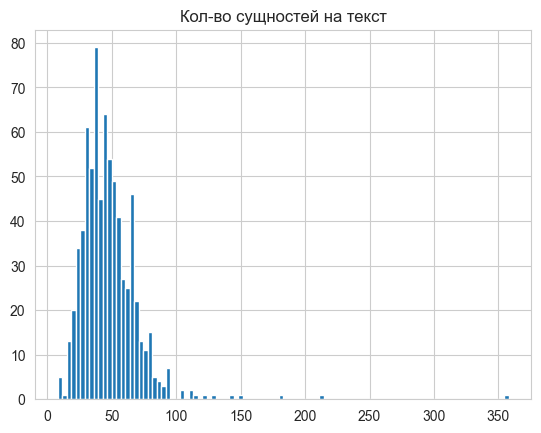

In [56]:
entity_cnt = []
for row in dataset["train"]:
    entity_cnt.append(len([item for item in row["tags"] if item.startswith("B-")]))

plt.hist(entity_cnt, bins=100)
plt.title("Кол-во сущностей на текст")
plt.show()

### Выводы по EDA
- и сущности и отношения (характеристики) которые нужно распознавать представлены в датасете неравномерно, распознавание редких сущности будет сложнее выучить
- также будет сложно выучить распознавание сущностей в длинных текстах (в датасете есть выбросы с очень большим кол-вом символов), где модели нужно выстаивать связи большого кол-ва токенов друг с другом

---

##### 3. Токенизация и выравнивание меток

Задачи:

- Выбрать `AutoTokenizer(..., use_fast=True)`.
- Реализовать `tokenize_and_align_labels(examples, tokenizer, label2id, max_length)`:
  - Токенизировать текст (return_offsets_mapping
  - Преобразовать word-level BIO метки в token-level метки (subword → label = -100 / ignore_index, для первых субтокенов ставится соответствующий тег `B-`/`I-`)
  - Вернуть словарь с `input_ids`, `attention_mask`, `labels` (token-level), `cls_labels`

- Собрать `torch.utils.data.Dataset` и `DataLoader`. Можно использовать `DataCollatorForTokenClassification` либо сделать кастомный collator, который возвращает батчи с `cls_labels`.



---
Тексты в датасете на русском. Нужно использовать токенизатор, который поддерживает русский язык.

Посмотрим на длину текстов в токенах

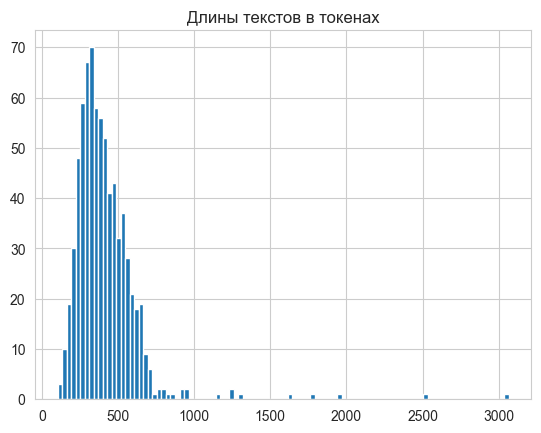

In [57]:
from transformers import AutoTokenizer

model_name = 'markussagen/xlm-roberta-longformer-base-4096'
# model_name = "DeepPavlov/rubert-base-cased"
# model_name = "deepvk/RuModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenized_texts = tokenizer(list(dataset["train"]["text"]), truncation=False)

token_lengths = [len(tokens) for tokens in tokenized_texts["input_ids"]]
plt.hist(token_lengths, bins=100)
plt.title("Длины текстов в токенах")
plt.show()

Много текстов довольно длинные, поэтому был выбран трансформер ~~xlm-roberta-longformer-base-4096 - мультиязычный roBERTa трансформер обученный с длиной контекста до 4096 токенов.~~ ~~`DeepPavlov/rubert-base-cased` (оказывается что с токенизаторов от этой модели большинство текстов попадают в окно 512 токенов)~~ `deepvk/RuModernBERT-base`

(xlm-roberta-longformer-base-4096 не зашёл, обучал его с контекстом 1024 со всех сторон много часов, но до 0.8 по cls f1 не дотянул)


Перенесем BIO-метки с уровня слов на уровень токенов

In [58]:
entity_labels = list(set([item.split("-")[1] for row in dataset["train"] for item in row["tags"] if "B-" in item]))
label2id = {lab: i for i, lab in enumerate(entity_labels)}
id2label = {i: lab for lab, i in label2id.items()}

def tokenize_and_align_labels(tokenizer, label2id, max_length=128):
    def _tokenize_and_align_labels(examples):
        tokenized = tokenizer(
            list(examples["text"]),
            # list(examples["tokens"]),
            # is_split_into_words=True,
            return_offsets_mapping=True,
            padding='max_length',
            truncation=True,
            max_length=max_length)
        labels = []
        for i, word_labels in enumerate(examples["tags"]):
            word_ids = tokenized.word_ids(batch_index=i)
            label_ids = []
            prev_word_idx = None
            for word_idx in word_ids:
                if word_idx is None:
                    label_ids.append(-100)
                elif word_idx != prev_word_idx:
                    label_id = -100
                    word_entity = "O"
                    if len(word_labels[word_idx].split("-")) == 2:
                        word_entity = word_labels[word_idx].split("-")[1]
                    label_id = label2id.get(word_entity, -100)
                    label_ids.append(label_id)
                else:
                    label_ids.append(-100)
                prev_word_idx = word_idx
            labels.append(label_ids)
        tokenized["labels"] = labels
        return tokenized
    return _tokenize_and_align_labels

tokenized_dataset = dataset["train"].map(
    tokenize_and_align_labels(tokenizer, label2id, max_length=768),
    batched=True,
    remove_columns=["text", "tokens", "tags", "token_spans"],
)

Map:   0%|          | 0/746 [00:00<?, ? examples/s]

Проверим что перенос корректный

In [59]:
list(zip(
    [tokenizer.decode(token) for token in tokenized_dataset["input_ids"][0]],
    tokenized_dataset["labels"][0],
    [id2label.get(tkn, "") for tkn in tokenized_dataset["labels"][0]]
))[:100]

[('<s>', -100, ''),
 ('Пу', -100, ''),
 ('ле', -100, ''),
 ('ме', -100, ''),
 ('ты', -100, ''),
 (',', -100, ''),
 ('автоматы', -100, ''),
 ('и', -100, ''),
 ('с', -100, ''),
 ('най', -100, ''),
 ('пер', -100, ''),
 ('ские', -100, ''),
 ('ви', -100, ''),
 ('нтов', -100, ''),
 ('ки', -100, ''),
 ('из', -100, ''),
 ('ъя', -100, ''),
 ('ты', -100, ''),
 ('в', -100, ''),
 ('аренду', -100, ''),
 ('ем', -100, ''),
 ('ом', -100, ''),
 ('американ', 27, 'NATIONALITY'),
 ('цами', -100, ''),
 ('доме', -100, ''),
 ('в', -100, ''),
 ('Бишкек', 25, 'CITY'),
 ('е', -100, ''),
 ('05', 8, 'TIME'),
 ('/08', -100, ''),
 ('/2008', -100, ''),
 ('10', 8, 'TIME'),
 (':35', -100, ''),
 ('Б', 25, 'CITY'),
 ('ИШ', -100, ''),
 ('КЕ', -100, ''),
 ('К', -100, ''),
 (',', -100, ''),
 ('5', 4, 'DATE'),
 ('августа', 4, 'DATE'),
 ('/', 6, 'ORGANIZATION'),
 ('Ново', -100, ''),
 ('сти', -100, ''),
 ('-', -100, ''),
 ('Г', -100, ''),
 ('ру', -100, ''),
 ('зия', -100, ''),
 ('/', -100, ''),
 ('.', -100, ''),
 ('Право', 6,

Объявляем `DataLoader` со стандартным `collate_fn=DataCollatorForTokenClassification`

In [60]:
from transformers import DataCollatorForTokenClassification
from torch.utils.data import DataLoader

data_collator = DataCollatorForTokenClassification(tokenizer)
train_dataloader = DataLoader(tokenized_dataset, batch_size=16, shuffle=True, collate_fn=data_collator)

---

##### 4. Модель: `JointModel` + custom loss (uncertainty weighting)


У нас готовы все данные, давайте создадим модель, которую потом будем обучать. К базовой модели, которую вы взяли на этапе выбора токенизатора, добавьте слой Dropout, линейный слой классификации сущностей и линейный слой классификации характеристик. Обратите внимание, что характеристики связаны со всем текстом, поэтому надо из всех эмбеддингов выбрать один, например, с помощью `[CLS]` пулинга. Обратите внимание, что `[CLS]` в квадратных скобках обозначает специальный токен, вектор которого нужно использовать для классификации текста.

Также реализуйте лосс-функцию для совместного обучения. Самый простой —  сумма лоссов для каждой задачи loss = token_loss + cls_loss.

In [61]:
import torch
from torch import nn
from transformers import AutoModel
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()


class JointModel(nn.Module):
    def __init__(self, config, label2id, features, pos_weight=None):
        super().__init__()
        self.base_model = AutoModel.from_pretrained(config.BASE_MODEL_NAME, ignore_mismatched_sizes=True)
        self.token_dropout = nn.Dropout(config.DROPOUT)
        self.cls_dropout = nn.Dropout(config.DROPOUT)

        self.use_uncertainty_weight = config.USE_UNCERTAINTY_WEIGHT

        self.entity_cnt = len(label2id)
        self.features_cnt = len(features)
        self.cls_term_multiplier = config.CLS_TERM_MULTIPLIER

        self.token_fc = nn.Linear(self.base_model.config.hidden_size, self.entity_cnt)
        self.attention_pool = nn.Linear(self.base_model.config.hidden_size, 1)
        self.cls_head = nn.Sequential(
            nn.Linear(self.base_model.config.hidden_size, config.CLS_HIDDEN_DIM),
            nn.LayerNorm(config.CLS_HIDDEN_DIM),
            nn.GELU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(config.CLS_HIDDEN_DIM, self.features_cnt)
        )

        self.log_sigma_token = nn.Parameter(torch.tensor(0.0))
        self.log_sigma_cls = nn.Parameter(torch.tensor(0.0))
        self.token_loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
        if pos_weight is not None:
            pos_weight = torch.tensor(pos_weight, dtype=torch.float)
        self.cls_loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.init_weights()

    def init_weights(self):
        for module in self.cls_head:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)
        nn.init.xavier_uniform_(self.token_fc.weight)
        nn.init.zeros_(self.token_fc.bias)
        nn.init.xavier_uniform_(self.attention_pool.weight)
        nn.init.zeros_(self.attention_pool.bias)

    def forward(self, input_ids, attention_mask, labels, cls_vec):
        embeddings = self.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        token_embeddings = self.token_dropout(embeddings.last_hidden_state)
        token_logits = self.token_fc(token_embeddings)

        cls_embeddings = self.cls_dropout(embeddings.last_hidden_state)
        # # CLS-logits
        # cls_logits = self.cls_fc(dropout_embeddings[:, 0])

        # # mean pooling
        # mask = attention_mask.unsqueeze(-1)
        # masked = dropout_embeddings * mask
        # mean_pooled = masked.sum(1) / mask.sum(1).clamp(min=1)
        # cls_logits = self.cls_fc(self.cls_hidden(mean_pooled))

        # attention pooling
        scores = self.attention_pool(cls_embeddings).squeeze(-1)
        scores = scores.masked_fill(attention_mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1)
        pooled = torch.sum(cls_embeddings * weights.unsqueeze(-1), dim=1)
        cls_logits = self.cls_head(pooled)

        token_loss = self.token_loss_fn(token_logits.view(-1, self.entity_cnt), labels.view(-1))
        cls_loss = self.cls_loss_fn(cls_logits, cls_vec.float())

        loss_token_term, loss_cls_term = torch.tensor(0.0), torch.tensor(0.0)
        if self.use_uncertainty_weight:
            loss_token_term = 0.5 * torch.exp(-2 * self.log_sigma_token) * token_loss + self.log_sigma_token
            loss_cls_term = 0.5 * torch.exp(-2 * self.log_sigma_cls) * cls_loss + self.log_sigma_cls
            loss = loss_token_term + loss_cls_term * self.cls_term_multiplier
        else:
            loss = token_loss + cls_loss * self.cls_term_multiplier

        return {
            "token_logits": token_logits,
            "cls_logits": cls_logits,
            "loss": loss,
            "loss_token_term": loss_token_term,
            "loss_cls_term": loss_cls_term,
        }

##### 5. Training / Validation



Когда логика модели прописана, можем начать ее обучать. Вот основые шаги, которые нужно выполнить:
- Настройте оптимизатор, LR-scheduler, gradient clipping.
- Обучите на достаточном количестве эпох. Можете воспользоваться значением с предыдущих уроков. Можно начать с 5 эпох и увеличивать, пока лосс не перестанет уменьшаться или пока не увидите переобучение.
- Рассчитайте качество на тестовой выборке. Используйте f1_score из библиотеки sklearn для каждой задачи:
   - По всем сущностям — F1 macro
   - По всем классам — F1 micro
- Соберите логи: для каждой эпохи выведите loss, token_f1, cls_f1.
- Сделайте выводы по проведённому обучению. На какой эпохе она обучилась, насколько лосс на обучении отличается от лосса на валидации на каждой задачи.

In [28]:
import torch
import random
import numpy as np
from tqdm.auto import tqdm


class Config:
    SEED = 42
    BASE_MODEL_NAME = "markussagen/xlm-roberta-longformer-base-4096"

    # Гиперпараметры
    BATCH_SIZE = 16
    BASE_LEARNING_RATE = 1e-5
    TOKEN_LEARNING_RATE = 5e-4
    CLS_LEARNING_RATE = 5e-4
    UNCERTAINTY_LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-2
    EPOCHS = 10
    DROPOUT = 0.3
    MAX_TOKENS = 1024
    UNFREEZE_LAYERS_PATTERN = "pooler|encoder"
    USE_UNCERTAINTY_WEIGHT = True
    CLS_TERM_MULTIPLIER = 1.
    CLS_HIDDEN_DIM = 128

    MODELS_PATH = "models"


def set_seed(seed=42):
    """
    Устанавливает сиды для всех источников случайности в PyTorch.
    """
    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Python
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # CuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Для некоторых операций — принудительно детерминистические алгоритмы
    torch.use_deterministic_algorithms(True, warn_only=True)

config = Config()
set_seed(config.SEED)

Изучим базовую модель, чтобы понять как к ней подступиться

In [63]:
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

print(AutoModel.from_pretrained(config.BASE_MODEL_NAME, ignore_mismatched_sizes=True))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel(
  (embeddings): XLMRobertaEmbeddings(
    (word_embeddings): Embedding(250002, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(4098, 768, padding_idx=1)
  )
  (encoder): XLMRobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x XLMRobertaLayer(
        (attention): XLMRobertaAttention(
          (self): XLMRobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): XLMRobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=Tr

Получается слой эмбедингов, 12 энкодеров и pooler слой для работы с представление CLS-токена. Для NER на нужен выход последнего энкодера, а для второй задачи мультиклассовой классификации нужен выход pooler-слоя

In [64]:
import torch
from torch.utils.data import random_split
from transformers import DataCollatorForTokenClassification
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from torch.utils.data import Subset

tokenizer = AutoTokenizer.from_pretrained(config.BASE_MODEL_NAME, use_fast=True)

data_collator = DataCollatorForTokenClassification(tokenizer)

entity_labels = list(set([item.split("-")[1] for row in dataset["train"] for item in row["tags"] if "B-" in item]))
label2id = {lab: i for i, lab in enumerate(entity_labels)}

tokenized_dataset = dataset["train"].map(
    tokenize_and_align_labels(tokenizer, label2id, max_length=config.MAX_TOKENS),
    batched=True,
    remove_columns=["text", "tokens", "tags", "token_spans"],
)

# tokenized_dataset = Subset(tokenized_dataset, list(range(50)))

train_dataset, val_dataset = random_split(tokenized_dataset, [0.9, 0.1], generator=torch.Generator().manual_seed(config.SEED))

train_dataloader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=data_collator)
val_dataloader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=data_collator)

Map:   0%|          | 0/746 [00:00<?, ? examples/s]

In [65]:
import numpy as np
from collections import Counter

# Собираем все векторы меток из train_dataset
all_labels = []
for sample in train_dataset:
    # cls_vec – это список/тензор из 0 и 1 длиной features_cnt
    all_labels.append(sample["cls_vec"])

# Преобразуем в numpy массив (N_samples, features_cnt)
all_labels = np.array(all_labels)

# Для каждого класса считаем pos_weight = num_negatives / num_positives
# Чтобы избежать деления на ноль, если положительных примеров нет, ставим большой вес или 1.0
num_pos = np.sum(all_labels, axis=0)
num_neg = all_labels.shape[0] - num_pos

# Стандартная формула pos_weight = num_neg / num_pos
# pos_weight = np.where(num_pos > 0, num_neg / num_pos, 1.0)  # если 0 положительных, weight=1
pos_weight = np.sqrt(num_neg / num_pos)

print("pos_weight per class:", pos_weight)

pos_weight per class: [0.47333256 0.1796053  0.32163376 0.37280431 0.49674264 0.60715355
 0.65326227 0.80189263 0.79689177 0.8872621  0.63476197 1.27878619
 1.67874412 2.11267949 1.58113883 2.27269391 1.97613499 2.13394447
 1.82633071 1.84960878 2.14476106 2.00372787 2.44948974 2.66390419
 2.23606798 2.37770169 2.02259959 2.55940653 2.24812234 2.909431  ]


In [66]:
from torchinfo import summary
import re


def set_requires_grad(module, unfreeze_pattern="", verbose=False):
    if len(unfreeze_pattern) == 0:
        for name, param in module.named_parameters():
            param.requires_grad = False
        return
    pattern = re.compile(unfreeze_pattern)
    for name, param in module.named_parameters():
        if pattern.search(name):
            param.requires_grad = True
            if verbose:
                print(f"Разморожен слой: {name}")
        else:
            param.requires_grad = False


model = JointModel(config, label2id, features, pos_weight)
set_requires_grad(model.base_model, unfreeze_pattern=config.UNFREEZE_LAYERS_PATTERN, verbose=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
print(f"Модель перенесена на девайс: {device}")
if torch.cuda.is_available():
    print(f"Девайс: {torch.cuda.get_device_name(0)}")

optimizer = torch.optim.AdamW([
        {'params': model.base_model.parameters(), 'lr': config.BASE_LEARNING_RATE, 'name': 'base_model'},
        {'params': model.token_fc.parameters(), 'lr': config.TOKEN_LEARNING_RATE, 'name': 'token_fc'},
        {'params': model.attention_pool.parameters(), 'lr': config.CLS_LEARNING_RATE, 'name': 'attention_pool'},
        {'params': model.cls_head.parameters(), 'lr': config.CLS_LEARNING_RATE, 'name': 'cls_head'},
        {"params": [model.log_sigma_token, model.log_sigma_cls], "lr": config.UNCERTAINTY_LEARNING_RATE, 'name': 'uncertainty'},
    ], weight_decay=config.WEIGHT_DECAY
)

print("Сводка о модели")
summary(model)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Разморожен слой: encoder.layer.0.attention.self.query.weight
Разморожен слой: encoder.layer.0.attention.self.query.bias
Разморожен слой: encoder.layer.0.attention.self.key.weight
Разморожен слой: encoder.layer.0.attention.self.key.bias
Разморожен слой: encoder.layer.0.attention.self.value.weight
Разморожен слой: encoder.layer.0.attention.self.value.bias
Разморожен слой: encoder.layer.0.attention.output.dense.weight
Разморожен слой: encoder.layer.0.attention.output.dense.bias
Разморожен слой: encoder.layer.0.attention.output.LayerNorm.weight
Разморожен слой: encoder.layer.0.attention.output.LayerNorm.bias
Разморожен слой: encoder.layer.0.intermediate.dense.weight
Разморожен слой: encoder.layer.0.intermediate.dense.bias
Разморожен слой: encoder.layer.0.output.dense.weight
Разморожен слой: encoder.layer.0.output.dense.bias
Разморожен слой: encoder.layer.0.output.LayerNorm.weight
Разморожен слой: encoder.layer.0.output.LayerNorm.bias
Разморожен слой: encoder.layer.1.attention.self.query.we

Layer (type:depth-idx)                                       Param #
JointModel                                                   2
├─XLMRobertaModel: 1-1                                       --
│    └─XLMRobertaEmbeddings: 2-1                             --
│    │    └─Embedding: 3-1                                   (192,001,536)
│    │    └─Embedding: 3-2                                   (768)
│    │    └─LayerNorm: 3-3                                   (1,536)
│    │    └─Dropout: 3-4                                     --
│    │    └─Embedding: 3-5                                   (3,147,264)
│    └─XLMRobertaEncoder: 2-2                                --
│    │    └─ModuleList: 3-6                                  85,054,464
│    └─XLMRobertaPooler: 2-3                                 --
│    │    └─Linear: 3-7                                      590,592
│    │    └─Tanh: 3-8                                        --
├─Dropout: 1-2                                             

In [29]:
from sklearn.metrics import f1_score
import json
import os
from datetime import datetime
from hashlib import sha256


def train_model(config, train_dataloader, val_dataloader, train_history=None):
    epoch_to_start = 1
    best_loss = 100
    cls_probabilities_thresholds = np.full(model.features_cnt, 0.5)

    if train_history is None:
        train_history = []
    if len(train_history) > 0:
        epoch_to_start = train_history[-1]["epoch"] + 1
        cls_probabilities_thresholds = train_history[-1]["cls_probabilities_thresholds"]
        if (train_history[-1]["val_cls_f1"] >= 0.75
                and train_history[-1]["val_token_f1"] >= 0.5):
            best_loss = train_history[-1]["val_loss"]

    scheduler = init_scheduler()

    for epoch in range(epoch_to_start, config.EPOCHS + epoch_to_start):
        model.train()
        device = next(model.parameters()).device

        epoch_loss, loss_token_term, loss_cls_term = 0.0, 0., 0.
        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch}"):
            inputs = {k: v.to(device) for k, v in batch.items()}
            if 'offset_mapping' in inputs:
                del inputs['offset_mapping']
            if 'token_type_ids' in inputs:
                del inputs['token_type_ids']
            optimizer.zero_grad()
            outputs = model(**inputs)
            loss = outputs["loss"]
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()
            loss_token_term += outputs["loss_token_term"].item()
            loss_cls_term += outputs["loss_cls_term"].item()

        train_loss = epoch_loss / len(train_dataloader)
        train_token_loss = loss_token_term / len(train_dataloader)
        loss_cls_loss = loss_cls_term / len(train_dataloader)

        if epoch >= 3:
            cls_probabilities_thresholds = find_best_thresholds(val_dataloader)
        val_losses = validate_model(model, val_dataloader, cls_probabilities_thresholds)
        current_lrs = {group['name']: group['lr'] for group in optimizer.param_groups}

        train_history_metadatum = {
            "epoch": epoch,
            "cls_probabilities_thresholds": cls_probabilities_thresholds,
            "learning_rates": current_lrs,
            "train_loss": train_loss,
            "val_loss": val_losses["loss"],
            "val_token_f1": val_losses["token_f1"],
            "val_cls_f1": val_losses["cls_f1"]
        }
        train_history.append(train_history_metadatum)
        if (val_losses["cls_f1"] >= 0.75
                and val_losses["token_f1"] >= 0.5
                and val_losses["loss"] < best_loss):
            best_loss = val_losses["loss"]
            save_model(model, config,
                additional_info=dict(train_history=train_history, **train_history_metadatum))

        print(
            f"train loss: {train_loss:.4f}\n"
            f"train token loss: {train_token_loss:.4f}\n"
            f"train cls loss: {loss_cls_loss:.4f}\n"
            f"val loss: {val_losses['loss']:.4f}\n"
            f"val token F1: {val_losses['token_f1']:.4f}\n"
            f"val cls F1: {val_losses['cls_f1']:.4f}"
        )
    return train_history


def init_scheduler():
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[
            config.BASE_LEARNING_RATE,
            config.TOKEN_LEARNING_RATE,
            config.CLS_LEARNING_RATE,
            config.CLS_LEARNING_RATE,
            config.UNCERTAINTY_LEARNING_RATE,
        ],
        steps_per_epoch=len(train_dataloader),
        epochs=config.EPOCHS,
        pct_start=0.1,            # 10% времени – подъём
        anneal_strategy='cos',    # косинусный спад в конце
        div_factor=25.0,          # начальный lr = max_lr / 25
        final_div_factor=1000.0,  # конечный lr = max_lr / 1000
    )
    return scheduler


def validate_model(model, val_dataloader, cls_probabilty_thresholds=None):
    model.eval()
    device = next(model.parameters()).device
    if cls_probabilty_thresholds is None:
        cls_probabilty_thresholds = np.full(model.features_cnt, 0.5)
    thresholds_tensor = torch.tensor(cls_probabilty_thresholds, device=device)

    epoch_val_loss = 0.0
    input_ids, token_raw_predicts, token_raw_labels = [], [], []
    token_labels, token_predicts, cls_labels, cls_predicts = [], [], [], []
    with torch.no_grad():
        for batch in val_dataloader:
            inputs = {k: v.to(device) for k, v in batch.items()}
            input_ids.extend(inputs["input_ids"].tolist())
            token_raw_labels.extend(inputs["labels"].tolist())
            if 'offset_mapping' in inputs:
                del inputs['offset_mapping']
            if 'token_type_ids' in inputs:
                del inputs['token_type_ids']
            outputs = model(**inputs)
            loss = outputs["loss"]
            epoch_val_loss += loss.item()

            token_raw_predicts.extend(torch.argmax(outputs["token_logits"], dim=-1).tolist())
            token_preds = torch.argmax(outputs["token_logits"], dim=-1).view(-1).cpu().tolist()
            labels = inputs["labels"].view(-1).cpu().tolist()
            for p, t in zip(token_preds, labels):
                if t != -100:
                    token_labels.append(int(t))
                    token_predicts.append(int(p))

            cls_labels.extend(inputs["cls_vec"].cpu().numpy())
            probs = torch.sigmoid(outputs["cls_logits"])
            preds = (probs > thresholds_tensor).int()
            cls_predicts.extend(preds.cpu().numpy())

    token_f1 = f1_score(token_labels, token_predicts, average="macro", zero_division=0)
    cls_f1 = f1_score(cls_labels, cls_predicts, average="micro", zero_division=0)

    return {
        "loss": epoch_val_loss / len(val_dataloader),
        "token_f1": token_f1,
        "cls_f1": cls_f1,
        "token_labels": token_raw_labels,
        "token_predicts": token_raw_predicts,
        "cls_labels": cls_labels,
        "cls_predicts": cls_predicts,
        "input_ids": input_ids,
    }


# def find_best_threshold(val_dataloader):
#     model.eval()
#     device = next(model.parameters()).device

#     all_probs = []
#     all_targets = []

#     with torch.no_grad():
#         for batch in val_dataloader:
#             inputs = {k: v.to(device) for k, v in batch.items()}

#             if 'offset_mapping' in inputs:
#                 del inputs['offset_mapping']
#             if 'token_type_ids' in inputs:
#                 del inputs['token_type_ids']

#             outputs = model(**inputs)

#             probs = torch.sigmoid(outputs["cls_logits"])

#             all_probs.append(probs.cpu())
#             all_targets.append(inputs["cls_vec"].cpu())

#     all_probs = torch.cat(all_probs).numpy()
#     all_targets = torch.cat(all_targets).numpy()

#     best_thr = 0.5
#     best_f1 = 0

#     for thr in np.arange(0.05, 0.95, 0.01):
#         preds = (all_probs > thr).astype(int)
#         f1 = f1_score(all_targets, preds, average="micro", zero_division=0)
#         if f1 > best_f1:
#             best_f1 = f1
#             best_thr = thr

#     return best_thr


def find_best_thresholds(val_dataloader):
    model.eval()
    device = next(model.parameters()).device

    all_probs = []
    all_targets = []
    with torch.no_grad():
        for batch in val_dataloader:
            inputs = {k: v.to(device) for k, v in batch.items()}
            if 'offset_mapping' in inputs:
                del inputs['offset_mapping']
            if 'token_type_ids' in inputs:
                del inputs['token_type_ids']
            outputs = model(**inputs)
            probs = torch.sigmoid(outputs["cls_logits"])
            all_probs.append(probs.cpu())
            all_targets.append(inputs["cls_vec"].cpu())
    all_probs = torch.cat(all_probs).numpy()
    all_targets = torch.cat(all_targets).numpy()
    num_classes = all_targets.shape[1]
    best_thresholds = np.zeros(num_classes)
    best_f1s = np.zeros(num_classes)
    for class_idx in range(num_classes):
        class_probs = all_probs[:, class_idx]
        class_targets = all_targets[:, class_idx]
        best_thr = 0.5
        best_f1 = 0.0
        for thr in np.arange(0.05, 0.95, 0.01):
            preds = (class_probs > thr).astype(int)
            f1 = f1_score(class_targets, preds, average='binary', zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thr = thr
        best_thresholds[class_idx] = best_thr
        best_f1s[class_idx] = best_f1
    return best_thresholds


def serialize_config(config):
    attrs_source = dict(config.__class__.__dict__)
    attrs = {k: v for k, v in attrs_source.items() if not k.startswith("__") and not callable(v)}
    return json.dumps(attrs, indent=4)


def load_config(json_data):
    if isinstance(json_data, str):
        data = json.loads(json_data)
    else:
        data = json_data 
    config_instance = Config()
    for key, value in data.items():
        setattr(config_instance, key, value)
    return config_instance


def save_model(model, config, additional_info={}):
    config_serialized = serialize_config(config)
    current_datetime = datetime.now()
    model_id = sha256(f"{config_serialized}/{current_datetime}".encode()).hexdigest()
    
    metadata = dict()
    metadata_path = f"{config.MODELS_PATH}/metadata.json"
    if os.path.exists(metadata_path):
        with open(metadata_path, "r+") as file:
            metadata = json.load(file)
    metadata[model_id] = {
        "config": config_serialized,
        **additional_info,
    }
    with open(metadata_path, "w") as file:
        json.dump(metadata, file, indent=4)
    
    model_path = f"{config.MODELS_PATH}/{model_id}.pth"
    torch.save(model.state_dict(), model_path)

    return model_path

In [68]:
# train_history = train_model(config, train_dataloader, val_dataloader)

In [69]:
# train_history = train_model(config, train_dataloader, val_dataloader, train_history)

In [70]:
# train_history = train_model(config, train_dataloader, val_dataloader, train_history)

In [71]:
# train_history_metadatum = {k: v for k, v in train_history[-1].items() if k in 
#     {"epoch", "cls_probabilities_threshold", "learning_rates", "train_loss", "val_loss", "val_token_f1", "val_cls_f1"}}
# save_model(model, config,
#     additional_info=dict(train_history=train_history, **train_history_metadatum))

In [25]:
import json

with open("models/metadata.json", "r") as file:
    metadata = json.load(file)

best_f1 = -100
for model_id, metadatum in metadata.items():
    if metadatum["val_cls_f1"] > best_f1:
        best_f1 = metadatum["val_cls_f1"]
        best_model_id = model_id

# best_model_id = list(metadata.keys())[0]

best_train_history = metadata[best_model_id]["train_history"]
print(f"best_model_id: {best_model_id}")

best_model_id: 377554c3c0497fb7410382bec3fd22444348b560348633340c7354546b3dfc57


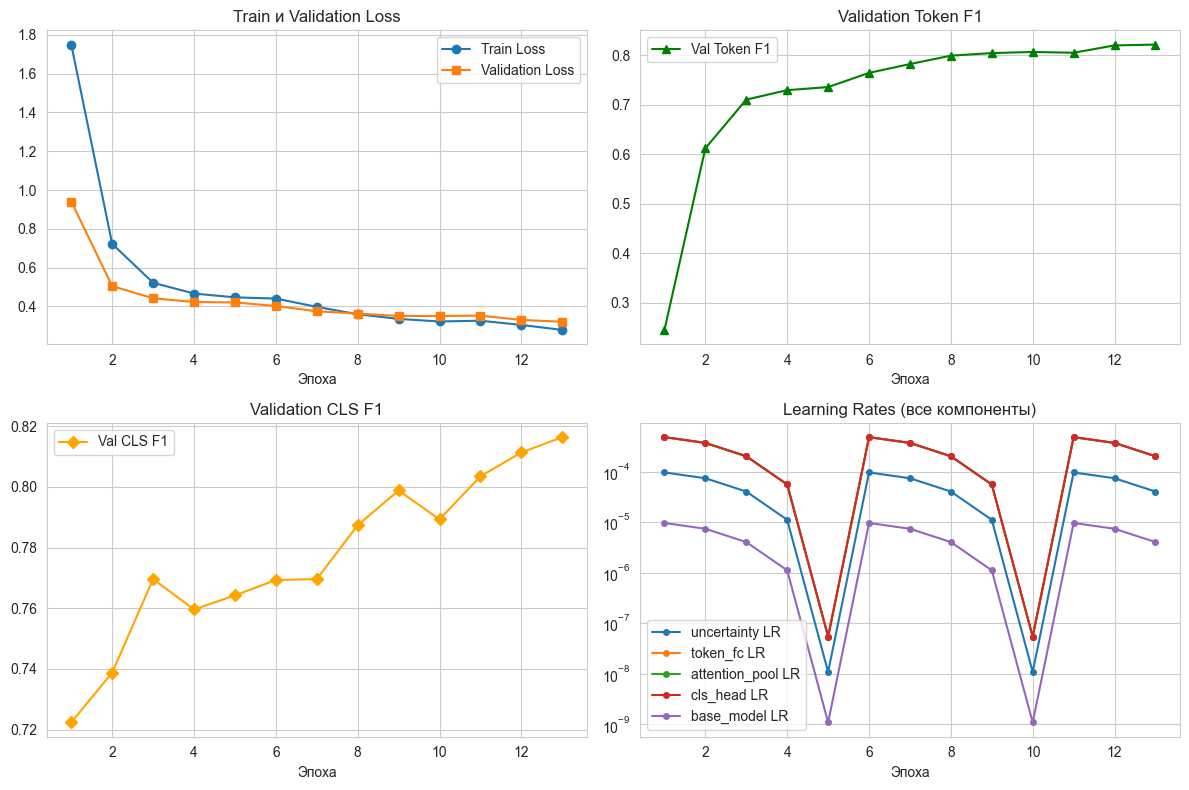

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

epochs = [entry['epoch'] for entry in best_train_history]
train_loss = [entry['train_loss'] for entry in best_train_history]
val_loss = [entry['val_loss'] for entry in best_train_history]
val_token_f1 = [entry['val_token_f1'] for entry in best_train_history]
val_cls_f1 = [entry['val_cls_f1'] for entry in best_train_history]

all_lr_types = set()
for entry in best_train_history:
    if 'learning_rates' in entry:
        all_lr_types.update(entry['learning_rates'].keys())
lr_data = {lr_type: [] for lr_type in all_lr_types}

for entry in best_train_history:
    if 'learning_rates' in entry:
        lr_dict = entry['learning_rates']
        for lr_type in all_lr_types:
            lr_data[lr_type].append(lr_dict.get(lr_type, None))

# График 1: Train и Validation Loss
plt.subplot(2, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='s')
plt.xlabel('Эпоха')
plt.title('Train и Validation Loss')
plt.legend()
plt.grid(True)

# График 2: Validation Token F1
plt.subplot(2, 2, 2)
plt.plot(epochs, val_token_f1, label='Val Token F1', color='green', marker='^')
plt.xlabel('Эпоха')
plt.title('Validation Token F1')
plt.legend()
plt.grid(True)

# График 3: Validation CLS F1
plt.subplot(2, 2, 3)
plt.plot(epochs, val_cls_f1, label='Val CLS F1', color='orange', marker='D')
plt.xlabel('Эпоха')
plt.title('Validation CLS F1')
plt.legend()
plt.grid(True)

# График 4: Learning Rate
plt.subplot(2, 2, 4)

for idx, lr_type in enumerate(lr_data.keys()):
    data = lr_data[lr_type]
    plt.plot(epochs, data, label=f'{lr_type} LR', marker='o', markersize=4)

plt.xlabel('Эпоха')
plt.title('Learning Rates (все компоненты)')
plt.legend()
plt.grid(True)
plt.yscale('log')

# Финальная настройка
plt.tight_layout()
plt.show()

##### 6. Инференс, квантизация и анализ ошибок

Проведите качественный анализ на 8–10 примерах: где NER ошибается? Какие типы сущностей плохо определяются? Насколько квантизация может ускорить инференс и сильно ли она ухудшает модель?


##### Заключение

Этот шаблон даёт вам чёткую дорожную карту и рабочие точки, где нужно реализовать код. В ноутбуке предоставлены только парсеры строкового формата - всё остальное вы пишете самостоятельно: токенизация/выравнивание меток, датасеты, модель, loss, тренировка и анализ.

Удачи - приступайте к реализации прямо в ноутбуке!

In [32]:
best_config = load_config(metadata[best_model_id]["config"])

print(f"Epoch: {metadata[best_model_id]["epoch"]}")
print("Config:")
print(metadata[best_model_id]["config"])

Epoch: 13
Config:
{
    "SEED": 42,
    "BASE_MODEL_NAME": "markussagen/xlm-roberta-longformer-base-4096",
    "BATCH_SIZE": 16,
    "BASE_LEARNING_RATE": 1e-05,
    "TOKEN_LEARNING_RATE": 0.0005,
    "CLS_LEARNING_RATE": 0.0005,
    "UNCERTAINTY_LEARNING_RATE": 0.0001,
    "WEIGHT_DECAY": 0.01,
    "EPOCHS": 5,
    "DROPOUT": 0.3,
    "MAX_TOKENS": 1024,
    "UNFREEZE_LAYERS_PATTERN": "pooler|encoder",
    "USE_UNCERTAINTY_WEIGHT": true,
    "CLS_TERM_MULTIPLIER": 1.0,
    "CLS_HIDDEN_DIM": 128,
    "MODELS_PATH": "models"
}


In [33]:
best_model = JointModel(best_config, label2id, features, pos_weight)
best_model.load_state_dict(torch.load(f"{config.MODELS_PATH}/{best_model_id}.pth", map_location=torch.device('cpu')))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RuntimeError: Error(s) in loading state_dict for JointModel:
	Missing key(s) in state_dict: "cls_fc.weight", "cls_fc.bias". 
	Unexpected key(s) in state_dict: "attention_pool.weight", "attention_pool.bias", "cls_head.0.weight", "cls_head.0.bias", "cls_head.1.weight", "cls_head.1.bias", "cls_head.4.weight", "cls_head.4.bias". 

In [23]:
val_output_data = validate_model(best_model, val_dataloader, metadata[best_model_id]["cls_probabilities_thresholds"])
val_output_data.keys()

print(
    f"val loss: {val_output_data['loss']:.4f}\n"
    f"val token F1: {val_output_data['token_f1']:.4f}\n"
    f"val cls F1: {val_output_data['cls_f1']:.4f}"
)

NameError: name 'best_model' is not defined

0.8163476461458872

In [157]:
id2label = {0: 'FACILITY',
 1: 'PERCENT',
 2: 'IDEOLOGY',
 3: 'TIME',
 4: 'NUMBER',
 5: 'NATIONALITY',
 6: 'WORK_OF_ART',
 7: 'PERSON',
 8: 'DATE',
 9: 'DISEASE',
 10: 'MONEY',
 11: 'DISTRICT',
 12: 'STATE_OR_PROVINCE',
 13: 'LOCATION',
 14: 'PROFESSION',
 15: 'ORGANIZATION',
 16: 'AWARD',
 17: 'ORDINAL',
 18: 'FAMILY',
 19: 'AGE',
 20: 'LAW',
 21: 'LANGUAGE',
 22: 'COUNTRY',
 23: 'EVENT',
 24: 'RELIGION',
 25: 'CRIME',
 26: 'PENALTY',
 27: 'PRODUCT',
 28: 'CITY'}

In [158]:
import pandas as pd
from transformers import AutoTokenizer

best_tokenizer = AutoTokenizer.from_pretrained(config.BASE_MODEL_NAME, use_fast=True)

def get_df_to_exxamine_token_predicts(sample_id):
    merged = list(zip(
        [best_tokenizer.decode(token) for token in val_output_data["input_ids"][sample_id]],
        val_output_data["token_labels"][sample_id],
        val_output_data["token_predicts"][sample_id],
    ))
    column_names = ["token", "label", "predict"]
    token_df = pd.DataFrame(merged, columns=column_names)
    token_df.loc[token_df['label'] == -100, 'predict'] = None
    token_df['label_name'] = token_df['label'].map(id2label)
    token_df['predict_name'] = token_df['predict'].map(id2label)

    with pd.option_context('display.max_rows', 100,
                        'display.max_columns', None,
                        'display.width', None,
                        'display.max_colwidth', None):
        display(token_df.head(100).fillna(''))

get_df_to_exxamine_token_predicts(0)

,token,label,predict,label_name,predict_name
0,<s>,-100,,,
1,Корол,3,0.0,TIME,FACILITY
2,ь,-100,,,
3,Бель,3,0.0,TIME,FACILITY
4,ги,-100,,,
5,и,-100,,,
6,Аль,26,3.0,PENALTY,TIME
7,бер,-100,,,
8,т,-100,,,
9,II,26,3.0,PENALTY,TIME


,token,label,predict,label_name,predict_name
0,<s>,-100,,,
1,Корол,19,5.0,PRODUCT,FAMILY
2,ь,-100,,,
3,Бель,-100,,,
4,ги,-100,,,
5,и,-100,,,
6,Аль,1,14.0,EVENT,LANGUAGE
7,бер,-100,,,
8,т,-100,,,
9,II,-100,,,


In [238]:
import os
import json


with open("models/metadata.json", "r") as file:
    metadata = json.load(file)

bad_models = []
for k, v in metadata.items():
    if v["val_loss"] > 0.5:
       bad_models.append(k)

for bad_model in bad_models:
    metadata.pop(bad_model)
    if os.path.exists(f"models/{bad_model}.pth"):
        os.remove(f"models/{bad_model}.pth")

with open("models/metadata.json", "w") as file:
    json.dump(metadata, file)